# Desi Bait: Engagement Bait Detection in South Asian YouTube

## 1. Introduction

Engagement bait comments like "Legends watching in 2026", "Maa ki lambi umar ke liye like karo", and "5 minute wali gang?" flood YouTube comment sections. While not harmful like spam, these comments drown out genuine feedback, questions, and discussions. The existing "Top" and "Newest" filters fail to detect them, making it difficult for creators and audiences to find meaningful engagement. 

This project builds a system to detect engagement bait in South Asian YouTube comments, with a focus on **Hinglish** (Hindi written in the Latin script) a major challenge for existing English-centric filters.

The project uses a two-phase approach:
1. **Phase 1:** Rule-based regex patterns (baseline)
2. **Phase 2:** Logistic Regression with TF-IDF features (ML)

## 2. Data Collection

Comments were scraped using the **YouTube API**. The following video categories were targeted because they are known to attract high volumes of engagement bait:

- **Devotional content** — comments often ask for "blessings" in the form of likes
- **Popular music videos and TV series episodes** — common sources of nostalgic, temporal, and identity-based bait
- **High-engagement creator videos** — channels with over 1 million subscribers (e.g., CarryMinati, Ashish Chanchlani, BB Ki Vines) were prioritised due to their active comment sections

### 2.1 Scraping with the YouTube API

The free tier of the YouTube API was used for this project, which was sufficient for the number of comments scraped.

To scrape a video, the **Video ID** is required, an 11‑character alphanumeric string found in the video URL after `?v=` or after the final slash.

> **Note:** Actual video IDs have been removed. The raw scraped data was saved as `desibait.csv` and loaded directly for cleaning and analysis.

In [1]:
from googleapiclient.discovery import build
from dotenv import load_dotenv
import os
import pandas as pd

In [6]:
#Load API
load_dotenv()
desikey = os.getenv('YOUTUBE_API_KEY')

if not desikey:
    raise ValueError('Key not found, Check your .env file')

desi_yt = build('youtube', 'v3', developerKey=desikey) 

In [24]:
#Function for scraping comments

def bakbakcollector(video_id, max_comments=50):                     #'bakbak' translates to 'chatter' in hindi
    bakbak = []
    next_page_token = None
    
    while len(bakbak) < max_comments:
        request = desi_yt.commentThreads().list(
            part='snippet',
            videoId=video_id,
            maxResults=100,
            pageToken=next_page_token,
            textFormat='plainText')
        response = request.execute()
        
        for item in response['items']:
            comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
            bakbak.append(comment)
            
            if len(bakbak) >= max_comments:
                break
            next_page_token = response.get('nextPageToken')
            if not next_page_token:
                break
        
    return bakbak

In [ ]:
#Defiining function to save to CSV
import csv
def savebakbak(new_comments, filename='desibait.csv'):
    df = pd.DataFrame(new_comments, columns=['comment'])

    if os.path.exists(filename):
        df.to_csv(filename, mode="a", header=False, index=False, encoding='utf-8', quoting=csv.QUOTE_ALL)
    else:
        df.to_csv(filename, mode="w", header=True, index=False, encoding='utf-8', quoting=csv.QUOTE_ALL)

    print(f"Saved {len(new_comments)} comments to {filename}")

In [36]:
#Scraping comments

video_ids = ['AbkEmIgJMcU','j18MRhEfmPk','53AJM6nWuUM','zmFygS2oGkw','q700cVAeB4g']
bakbak_2 = []

for vid in video_ids:
    print(f"Scraping video: {vid}")
    comments = bakbakcollector(vid, max_comments=150)
    bakbak_2.extend(comments)

savebakbak(bakbak_2)

Scraping video: AbkEmIgJMcU
Scraping video: j18MRhEfmPk
Scraping video: 53AJM6nWuUM
Scraping video: zmFygS2oGkw
Scraping video: q700cVAeB4g
Saved 750 comments to desibait.csv


## 3. Cleaning & Preprocessing

- **750 comments** were initially scraped.
- Applied regex-based cleaning and normalisation, including lowercasing, removing URLs, emojis, punctuation, special characters, and extra whitespace.
- Manually reviewed the dataset to remove duplicates, correct spelling errors, and eliminate nonsensical or irrelevant comments.
- Labelled each comment as **bait (1)** or **genuine (0)** and by language: **English (0)**, **Hinglish (1)**, and **Mixed (2)**.

In [3]:
#Cleaning
import csv

desibaits = []
with open('desibait.csv','r',encoding='utf-8') as file:
    read = csv.reader(file)
    next(read)
    for line in read:
        desibaits.append(line[0])

print(len(desibaits))
print(desibaits[:10])

750
['Tera mera afsana...', 'Listening this masterpiece today!! 🖤🙂', 'Dkgiudghig😅', 'Anyone today??', 'I used to hear this after my breakup and i used to remember him...but as i am moving on ,i am starting to enjoy this song without thinking of someone & its so relaxing..i love the song❤❤', 'Anyone 28 feb', '🕊️✨🌔🌊', '❤', '28 feb 2026❤', 'Lovely song in the world']


In [15]:
#Regex cleaning
import re
import string

def safai(text):
    text = text.lower()     #lowercase
    text = re.sub(r'http\S+','', text)
    text = text.translate(str.maketrans('','', string.punctuation))
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = " ".join(text.split())
    return text

In [43]:
saafcomments = [safai(d) for d in desibaits if (cleaned:= safai(d))!= '']
print(saafcomments)

['tera mera afsana', 'listening this masterpiece today', 'dkgiudghig', 'anyone today', 'i used to hear this after my breakup and i used to remember himbut as i am moving on i am starting to enjoy this song without thinking of someone its so relaxingi love the song', 'anyone 28 feb', '28 feb 2026', 'lovely song in the world', 'night 11pm anyone', '112 that feeling', 'this is not a song it is a feeling', 'anyone in 28 feb', 'anyine tommor', 'this is for my friend komal sharma due to misunderstanding she lefts me and ihe take right decision every girl take same but in some day i am to much miss her she is to good i am tell her to much bull shit that she cant even digest i think i fell in love with you komal sharma this incident made me a man with dead heart for the 1 time i fell in love before that 4 5 girl purpose me but i like her and whom 1st time i like in my life would live this is my last i love you komal sharma and i am not have courage to tell you this life i have to much responsi

In [ ]:
#Save cleaned 
df = pd.DataFrame(saafcomments, columns=['comment'])
df.to_csv('desibait_cleaned.csv', index=False, encoding='utf-8')

## 4. Data Augmentation

To address label and language imbalances, pattern-based augmentation was applied using the EDA framework **(Wei & Zou, 2019).** Variations were created using following techniques:
- **Synonym Replacement**
- **Random Insertion**
- **Random Swap**
- **Random Deletion**

Unlike the original EDA implementation (which uses WordNet for English), I applied these techniques **manually** to ensure linguistic authenticity for Hinglish code-switched text. The final dataset consisting **576** comments was saved as **desibait_final.csv**

In [4]:
#FINAL DATA SUMMARY
import pandas as pd
data2 = pd.read_csv('desibait_final.csv')

print('NEW DATASET SUMMARY')
print('Total comments:', len(data2))
print('\nLabel Distribution:', data2['label'].value_counts())
print('\nLanguage Distribution:', data2['language'].value_counts())
print('\nLanguage x Label Cross Tab')
cross2 = pd.crosstab(data2['language'], data2['label'])
print(cross2)

NEW DATASET SUMMARY
Total comments: 576

Label Distribution: label
0    324
1    252
Name: count, dtype: int64

Language Distribution: language
1    290
0    270
2     16
Name: count, dtype: int64

Language x Label Cross Tab
label       0    1
language          
0         164  106
1         147  143
2          13    3


# 5. Phase 1: Rule-Based (Heuristic) Approach

The first approach uses a rule‑based system with **regular expressions (regex)** to identify engagement bait patterns. Rule‑based methods are:
- Simple and interpretable
- Computationally lightweight
- Easy to update and maintain
- Reflective of real‑world moderation systems (e.g., YouTube's spam filters)


In [13]:
#Importing necessary libraries
import re
from collections import Counter

#Filter bait comments
desi_comments = data2[data2['label'] == 1]['comment'].tolist()

#Combine all bait comments into one string
desi_text = ' '.join(desi_comments).lower()

#Print output
print(desi_text)

listening this masterpiece today? anyone today anyone 28 feb night 11pm anyone anyone in 28 feb talwinder fans like who is listening during boards like this comment so i can come back to this masterpiec everyone today anyone 1 february any 01 march listeners botton for talwinder anyone on 28 february 2026 anyone anyone 28 february i have an exam in an hour today and i have come to hear this anyone in class 12 students few hours before sanskrit 2026 anyone 2722026 27-feb anu one february 27 kon kon student hai anyone today sad i m leaving this commentso that anyone gives a thums upit vl remind me to cum bak n listen this masterpieceby the way today is 26226 01-mar march 2026 attendance 1st march attendance todays attendance 28 february attendance 28th february 5 march attandance ajj kon kon suna raha hai march 1 jo jo aj propose karne wala hai who got kissan ad before 29 feb attendance any attempt 28 feburary 126 20-feb kon kon ka one sided love he bataw who is listening 28feb 17-mar 28

### 5.1 Pattern Derivation

Patterns were derived from **frequency analysis** of bait comments, focusing on recurring lexical cues:
Stopwords (e.g., `hai`, `se`, `ke`, `in`) were retained in bigrams and trigrams to preserve phrasal patterns like `exam me fail` and `stream ke baad`, but were excluded from unigrams to surface content-bearing words such as `like`, `kon`, and `2026`. 

The resulting pattern list was used to build a regex‑based classifier. Some patterns were added even though they did not appear among the most frequent words, bigrams, or trigrams identified during frequency analysis. These patterns were observed elsewhere in the dataset through manual inspection and were included because they represent characteristic engagement-bait behaviour on YouTube. This combination of frequency analysis and domain knowledge helps produce a more comprehensive rule set.

| Category | Examples |
|----------|----------|
| Direct requests | `like karo`, `vote karo`, `reply de do`, `like if you`, `comment if you`|
| Identity/Group bait | `kon kon`, `gang`, `dekhne wale` |
| Temporal bait | `2026`, `watching in`, `stream ke baad` |
| Religious/Emotional bait | `maa ki lambi umar`, `hanuman ji ke`, `kasam`, `exam me fail` |

In [19]:
#Finding words, bigrams & trigrams for frequency analysis

#Import libraries
import re
from collections import Counter

#Defining the function
def patternkhoj(desi_text, desi_comments):

    #WORDS
    words = re.findall(r'\b[a-zA-Z0-9]+\b', desi_text) #---------------------only keeps alphabetical and numerical elements
    word_freq = Counter(words)
    print('-'*50)
    print('TOP 30 WORDS IN BAIT COMMENTS') 
    print('-'*50)
    for word, count in word_freq.most_common(30): 
        print(f'{word}:{count}')
    
    #BI-GRAMS
    bigrams = [] #-----------------------------------------------------------empty list to store bigrams
    for d in desi_comments:
        bigram_list = re.findall(r'\b[a-zA-Z0-9]+\b', d.lower()) #-----------only keeps alphabetical and numerical elements
        for i in range(len(bigram_list) - 1):
            bigrams.append(' '.join(bigram_list[i:i+2]))
    
    bigram_freq = Counter(bigrams)
    print('-'*50)
    print('\nTOP 30 BIGRAMS IN BAIT COMMENTS') 
    print('-'*50)
    for bigram, count in bigram_freq.most_common(30): 
        print(f'{bigram}:{count}')

    #TRI-GRAMS
    trigrams = []  #----------------------------------------------------------empty list for trigrams
    for d in desi_comments:
        trigram_list = re.findall(r'\b[a-zA-Z0-9]+\b', d.lower()) #-----------only keeps alphabetical and numerical elements 
        for i in range(len(trigram_list) - 2):
            trigrams.append(' '.join(trigram_list[i:i+3]))
    
    trigram_freq = Counter(trigrams)
    print('-'*50)
    print('\nTOP 30 TRIGRAMS IN BAIT COMMENTS') 
    print('-'*50)
    for trigram, count in trigram_freq.most_common(30):
        print(f'{trigram}:{count}')
    
    return { 'word_freq': word_freq,
            'bigram_freq': bigram_freq,
            'trigram_freq': trigram_freq}

In [25]:
#Executing the function
phase1_freq = patternkhoj(desi_text, desi_comments)
print(phase1_freq)

--------------------------------------------------
TOP 30 WORDS IN BAIT COMMENTS
--------------------------------------------------
kon:78
hai:59
like:51
dekh:38
watching:33
raha:30
se:27
2026:25
in:24
ke:24
karo:21
who:20
me:20
anyone:19
drama:19
this:18
ki:18
i:16
jo:15
wale:14
is:13
comment:13
to:13
1:13
exam:13
time:13
aaj:13
dekhne:13
bhi:12
kis:12
--------------------------------------------------

TOP 30 BIGRAMS IN BAIT COMMENTS
--------------------------------------------------
kon kon:38
dekh raha:24
raha hai:20
like karo:14
hai like:13
dekhne wale:11
who is:10
watching this:9
se dekh:8
se dekhne:8
exam ke:8
pehle dekh:8
watching in:7
i am:7
wale kon:7
student hai:6
is watching:6
how many:6
this drama:6
in 2026:6
yaar koi:6
bangladesh se:6
kis kis:6
kis ko:6
kon drama:6
wali gang:6
ke baad:6
ke liye:6
like kardo:6
dekh rha:5
--------------------------------------------------

TOP 30 TRIGRAMS IN BAIT COMMENTS
--------------------------------------------------
dekh raha hai:17
s

In [31]:
#Save the results
with open('desibait_phase1.txt', 'w', encoding='utf-8') as file:

    file.write('TOP 30 WORDS IN BAIT COMMENTS')
    file.write('-' * 30 + '\n')

    for word, count in phase1_freq['word_freq'].most_common(30):
        file.write(f"{word}: {count}\n")

    file.write('\nTOP 30 BIGRAMS IN BAIT COMMENTS\n')
    file.write('-' * 30 + '\n')

    for bigram, count in phase1_freq['bigram_freq'].most_common(30):
        file.write(f"{bigram}: {count}\n")

    file.write('\nTOP 30 TRIGRAMS IN BAIT COMMENTS\n')
    file.write('-' * 30 + "\n")

    for trigram, count in phase1_freq['trigram_freq'].most_common(30):
        file.write(f"{trigram}: {count}\n")

## 5.2 Classification Function

The function loops through each comment and checks if any pattern matches. If a match is found, the comment is classified as bait (1); otherwise, it is classified as genuine (0).

In [6]:
#MAKING A LIST OF PATTERNS

import re
desi_patterns = [ 
    #---------------------------------
    #DIRECT REQUESTS
    #---------------------------------
    r'like\s*(karo|kardo|kro|kar do)',
    r'vote\s*karo',
    r'reply\s*de\s*do',
    r'comment\s*karo',
    r'attendance',                           
    r'attendance\s*(lagao|karo)',
    r'like\s*if\s*you',                      
    r'comment\s*if\s*you',
    
    #---------------------------------
    #IDENTITY & GROUP BAIT
    #---------------------------------
    r'(kon|kaun)\s*(kon|kaun)',
    r'kis\s*kis\s*ko', 
    r'gang', 
    r'minute\s*wali\s*gang',
    r'student|exam|bangladesh|russian',
    r'dekhne\s*wale',
    r'[a-zA-Z]+\s*fans\s*like', 
    
    #----------------------------------
    #TEMPORAL BAIT
    #----------------------------------
    r'20[0-9]{2}',
    r'watching\s*in\s*20[0-9]{2}',
    r'legends\s*watching\s*(in|after)',
    r'stream\s*ke\s*baad', 
    r'anyone\s*(today|now|tonight|here)',  
    #anyone on/in + day + month
    r'anyone\s*(?:in|on)\s*\d{1,2}\s*(?:jan(?:uary)?|feb(?:ruary)?|mar(?:ch)?|apr(?:il)?|may|jun(?:e)?|jul(?:y)?|aug(?:ust)?|sep(?:tember)?|oct(?:ober)?|nov(?:ember)?|dec(?:ember)?)',
    #anyone + day + month (without 'in'/'on')
    r'anyone\s*\d{1,2}\s*(?:jan(?:uary)?|feb(?:ruary)?|mar(?:ch)?|apr(?:il)?|may|jun(?:e)?|jul(?:y)?|aug(?:ust)?|sep(?:tember)?|oct(?:ober)?|nov(?:ember)?|dec(?:ember)?)',
    #anyone + year (with or without 'in')
    r'anyone\s*(?:in\s*)?20\d{2}',
    r'who\s*is\s*(?:watching|listening|here)',
    r'everyone\s*(today|now|tonight)', #everyone comments

    #------------------------------------
    #RELIGIOUS & EMOTIONAL BAIT
    #------------------------------------   
    r'maa\s*ki\s*lambi\s*umar',
    r'hanuman\s*ji\s*ke',  
    r'aaj\s*pata\s*chala',         
    r'hanuman\s*ji\s*ke\s*liye\s*like',                             
    r'parents\s*(live|ki)\s*100\s*years',
    r'kasam|shapath',
    r'exam\s*me\s*fail'] 

#THIS LIST CAN BE UPDATED WITH NEW PATTERNS, just add a comma after the last pattern and continue!

In [11]:
#Defining function for pattern identification

def baitmilgaya(comment):                      #'mil gaya' = 'found' in Hindi
    text = comment.lower()
    for pattern in desi_patterns: 
        if re.search(pattern, text):  #loops through every comment in dataset to match patterns in pattern list
            return 1
    return 0

#We had already imported our data and stored in the variable 'data2' before phase 1
phase1_results = data2['phase_1'] = data2['comment'].apply(baitmilgaya) 
print(data2[['comment', 'label', 'phase_1']].head(20))

                                              comment  label  phase_1
0                                    tera mera afsana      0        0
1                   listening this masterpiece today?      1        0
2                                        anyone today      1        1
3   i used to hear this after my breakup and i use...      0        0
4                                       anyone 28 feb      1        1
5                            lovely song in the world      0        0
6                                   night 11pm anyone      1        0
7                                   1:12 that feeling      0        0
8                  this is not a song it is a feeling      0        0
9                                    anyone in 28 feb      1        1
10  this is for my friend komal sharma due to misu...      0        0
11  ive been on this for last 3 months from dec 18...      0        1
12                                talwinder fans like      1        1
13                  

In [13]:
#Saving the results in CSV
data2.to_csv('desibait_phase1.csv', index=False)

### 5.3 Phase 1 - Evaluation and Metrics
| Metric | Score |
|--------|-------|
| Accuracy | 82.3% |
| Precision (Bait) | 87.9% |
| Recall (Bait) | 69.0% |
| F1-Score (Bait) | 77.3% |

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

#Get predictions
y_true = data2['label']
y_pred = data2['phase_1']

print('\n' + '=' * 60)
print('PHASE 1 PERFORMANCE')
print('=' * 60)

print(f'Accuracy: {accuracy_score(y_true, y_pred)}')
print(f'Precision: {precision_score(y_true, y_pred)}')
print(f'Recall: {recall_score(y_true, y_pred)}')
print(f'F1 Score: {f1_score(y_true, y_pred)}')

print('\n' + '-' * 60)
print('\nClassification Report')
print(classification_report(y_true, y_pred))


PHASE 1 PERFORMANCE
Accuracy: 0.8229166666666666
Precision: 0.8787878787878788
Recall: 0.6904761904761905
F1 Score: 0.7733333333333333

------------------------------------------------------------

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.93      0.85       324
           1       0.88      0.69      0.77       252

    accuracy                           0.82       576
   macro avg       0.84      0.81      0.81       576
weighted avg       0.83      0.82      0.82       576



### 5.3.1  Interpretation

| Metric | What It Tells Us |
|--------|------------------|
| **High Precision for Bait (87.9%)** | When the system flagged a comment as bait, it was correct nearly 9 out of 10 times. False positives are low. |
| **Lower Recall for Bait (69.0%)** | The system missed about 31% of actual bait comments. This suggests that some bait patterns were not captured by the current rule set. |
| **High Recall for Genuine (93%)** | The system correctly identified 93% of genuine comments — very few genuine comments were wrongly flagged as bait. |
| **Accuracy (82.3%)** | Overall, the system performed well as a baseline, correctly classifying over 8 out of 10 comments. |

### 5.3.2  Limitations

The rule‑based system relies on explicit patterns & struggles with creative variations of known patterns such as difference in spelling or phrasing.


# 6. PHASE 2: Machine Learning

### Overview

Phase 2 uses a **Logistic Regression** classifier to improve upon the rule-based baseline. The text is vectorised using **TF-IDF** and a custom Hinglish stopword list combined with English stopwords is applied.


In [3]:
#Importing data
import pandas as pd
data3 = pd.read_csv('desibait_final.csv')

### 6.2 Splitting data for training

- **Train-test split:** 80% training, 20% testing (stratified)
- **Vectorisation:** TF-IDF with `max_features=2000` and `ngram_range=(1, 2)`
- **Stopwords:** Custom list (English + Hinglish)

In [7]:
#Defining X & y

from sklearn.model_selection import train_test_split

X = data3['comment']
y = data3['label']

#Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training {len(X_train)} | Testing: {len(X_test)}')

Training 460 | Testing: 116


In [27]:
#Preparing for vectorisation
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

#Create list of Hinglish stopwords (as observed in dataset)
hinglish_stopwords = {
    'hai', 'hain', 'ho', 'hon', 'raha', 'rahi', 'rahe', 'tha', 'thi', 'the',
    'se', 'ke', 'ki', 'ko', 'ka', 'kya', 'ye', 'wo', 'wahi', 'bhi', 'hi',
    'me', 'ne', 'to', 'na', 're', 'lo', 'de', 'diya', 'di', 'liya', 'li',
    'ab', 'tab', 'jab', 'kab'
}

#Combine sets
desi_stopwords = set(ENGLISH_STOP_WORDS)  #start with scikit‑learn's English stopwords
desi_stopwords.update(hinglish_stopwords)  #adding our Hinglish stopwords

#Use in TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
desi_vectors = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    stop_words=list(desi_stopwords)  #pass the combined list
)

### 6.3 Model Training

```python
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)
```

In [11]:
#Fit on training data
X_train_vec = desi_vectors.fit_transform(X_train)
X_test_vec = desi_vectors.transform(X_test)

#Model training
from sklearn.linear_model import LogisticRegression
desimodel = LogisticRegression(max_iter=1000, random_state=42)
desimodel.fit(X_train_vec, y_train)

#Predict
y_pred = desimodel.predict(X_test_vec)

#Print
print(y_pred[:10])

[0 0 0 0 0 0 1 0 1 0]


## 6.4 Phase 2 - Evaluation & Metrics
| Metric | Score |
|--------|-------|
| Accuracy | 84.5% |
| Precision (Bait) | 90.2% |
| Recall (Bait) | 72.5% |
| F1-Score (Bait) | 80.4% |

In [15]:
#Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#Accuracy, Precision, Recall, F1
accuracy_2 = accuracy_score(y_test, y_pred)
precision_2 = precision_score(y_test, y_pred)
recall_2 = recall_score(y_test, y_pred)
f1score_2 = f1_score(y_test, y_pred)

print('\n' + '=' * 60)
print('PHASE 2 PERFORMANCE')
print('=' * 60)
print(f'Accuracy: {accuracy_2:.4f}')
print(f'Precision: {precision_2:.4f}')
print(f'Recall: {recall_2:.4f}')
print(f'F1 Score: {f1score_2:.4f}')

#Classification Report
print('\n' + '-' * 60)
print('\nClassification Report')
print(classification_report(y_test, y_pred))


PHASE 2 PERFORMANCE
Accuracy: 0.8448
Precision: 0.9024
Recall: 0.7255
F1 Score: 0.8043

------------------------------------------------------------

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        65
           1       0.90      0.73      0.80        51

    accuracy                           0.84       116
   macro avg       0.86      0.83      0.84       116
weighted avg       0.85      0.84      0.84       116



### 6.4.1 Interpretation

| Metric | What It Tells Us |
|--------|------------------|
| **High Precision for Bait (90.2%)** | When the model flagged a comment as bait, it was correct over 9 out of 10 times. False positives are very low i.e. only about 10% of flagged comments were actually genuine. |
| **Good Recall for Bait (72.5%)** | The model caught about 73% of actual bait comments. This means it missed around 27% of bait comments, which is a considerable improvement over Phase 1's 31% miss rate. |
| **Very High Recall for Genuine (94%)** | The model correctly identified 94% of genuine comments. Only 6% of genuine comments were wrongly flagged as bait, a very low false positive rate. |
| **Accuracy (84.5%)** | Overall, the model correctly classified over 8 out of 10 comments, improving on the Phase 1 baseline. |

#### Key Takeaway

Phase 2 improved across all metrics. The largest growth was in **recall (+3.5%)**, meaning the ML model caught more bait comments than the rule‑based system. This confirms that machine learning can capture patterns that explicit rules miss, while maintaining as well as improving precision.

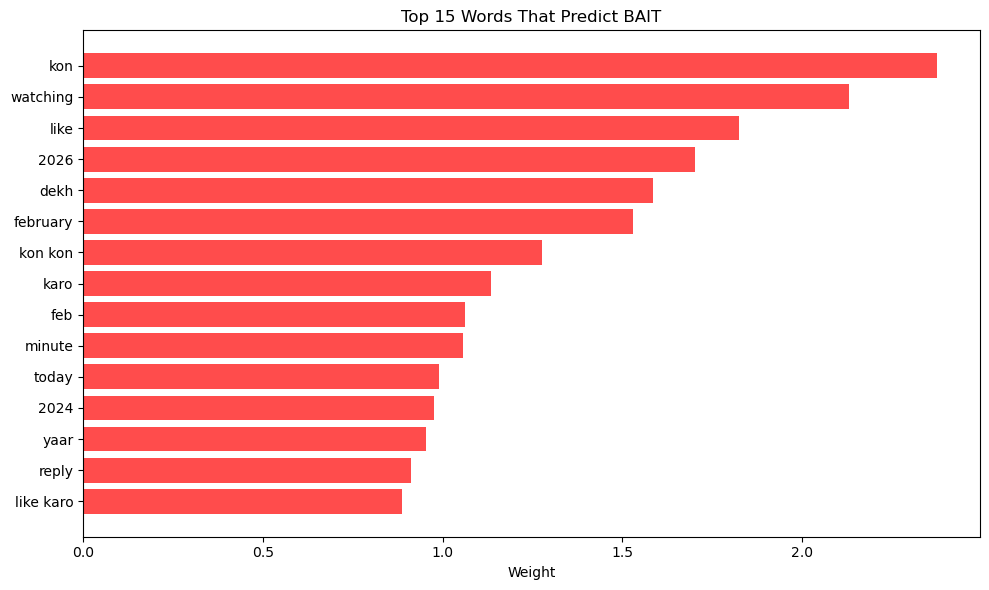

TOP BAIT WORDS (positive weights):
  kon: 2.376
  watching: 2.131
  like: 1.824
  2026: 1.703
  dekh: 1.585
  february: 1.529
  kon kon: 1.277
  karo: 1.134
  feb: 1.062
  minute: 1.055
  today: 0.991
  2024: 0.977
  yaar: 0.954
  reply: 0.911
  like karo: 0.886


In [17]:
#Explainability

import pandas as pd
import matplotlib.pyplot as plt

#Get feature names and weights
feature_names = desi_vectors.get_feature_names_out()
weights = desimodel.coef_[0]

#Create DataFrame
word_importance = pd.DataFrame({
    'word': feature_names,
    'weight': weights
}).sort_values('weight', ascending=False)

#Top 15 bait words
top_bait = word_importance.head(15)

#Plot
plt.figure(figsize=(10, 6))
plt.barh(top_bait['word'], top_bait['weight'], color='red', alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Weight')
plt.title('Top 15 Words That Predict BAIT')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print the list
print('TOP BAIT WORDS (positive weights):')
for idx, row in top_bait.iterrows():
    print(f"  {row['word']}: {row['weight']:.3f}")

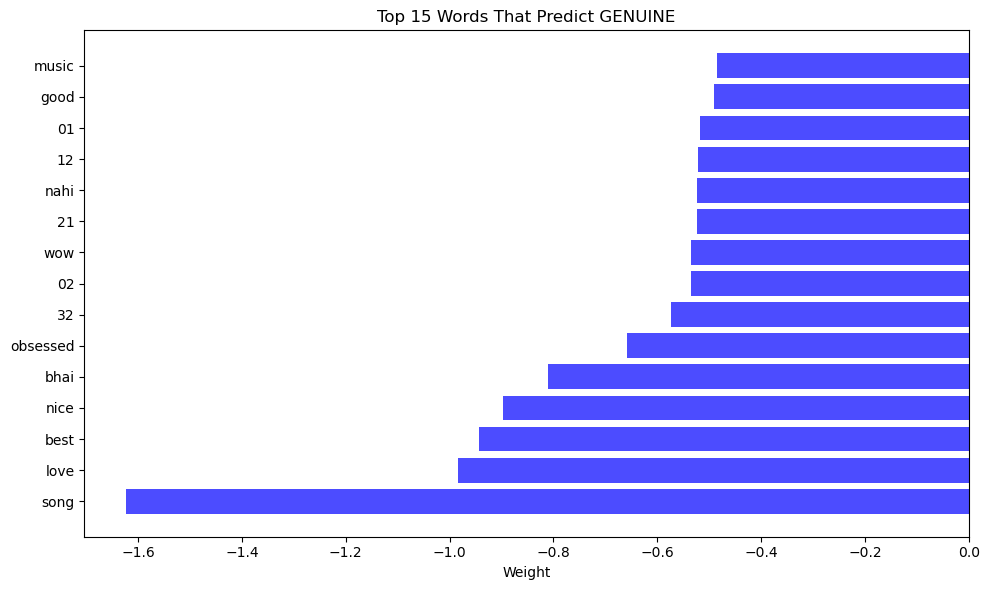


Top genuine words (negative weights):
  music: -0.484
  good: -0.490
  01: -0.517
  12: -0.521
  nahi: -0.524
  21: -0.524
  wow: -0.534
  02: -0.535
  32: -0.573
  obsessed: -0.658
  bhai: -0.811
  nice: -0.897
  best: -0.944
  love: -0.983
  song: -1.622


In [19]:
# Top 15 genuine words
top_genuine = word_importance.tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_genuine['word'], top_genuine['weight'], color='blue', alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Weight')
plt.title('Top 15 Words That Predict GENUINE')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop genuine words (negative weights):")
for idx, row in top_genuine.iterrows():
    print(f"  {row['word']}: {row['weight']:.3f}")

## Explainability: Feature Weights

Logistic Regression provides interpretable feature weights. A **positive weight** pushes the prediction toward bait, while a **negative weight** pushes it toward genuine.

**Key Insight:** The model's top bait signals align closely with the patterns identified in Phase 1, confirming that the model has learned meaningful, culturally relevant features.